In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuration
log_file = 'training_logs/5_kfold_gcn_sensor_graph_20260429_011202.csv'
METRIC_COLS = ['Train_MSE', 'Val_MSE', 'Val_RMSE', 'Val_MAE', 'Val_R2']

if not os.path.exists(log_file):
    print(f"Error: File {log_file} not found.")
else:
    # Improved Loading: Skip metadata by searching for the header row
    # If your file consistently starts data on line 53, skiprows=52 is fine,
    # but using comment='#' helps ignore configuration lines if they are prefixed.
    df_raw = pd.read_csv(log_file, skiprows=0, comment='#')

    # Clean data: Remove rows that aren't epoch records (e.g., summary stats)
    df = df_raw[pd.to_numeric(df_raw['Fold'], errors='coerce').notnull()].copy()
    
    # Cast types correctly
    df['Fold'] = df['Fold'].astype(int)
    df['Epoch'] = df['Epoch'].astype(int)
    for col in METRIC_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"Successfully loaded {len(df)} records.")
    print(f"Folds detected: {df['Fold'].unique()}")
    print(df.head())

Successfully loaded 1197 records.
Folds detected: [1 2 3 4 5]
   Epoch   Train_MSE     Val_MSE   Val_RMSE   Val_MAE    Val_R2  Fold  \
0      1  137.913884  121.315923  11.014351  8.612758 -1.532930     1   
1      2   75.494848   34.582262   5.880668  4.839535  0.277964     1   
2      3   30.009933   19.955978   4.467211  3.717182  0.583343     1   
3      4   18.940021   13.222005   3.636208  2.841024  0.723940     1   
4      5   14.805318   10.260179   3.203151  2.327088  0.785780     1   

   Total_Params  Trainable_Params  
0         25002             25002  
1         25002             25002  
2         25002             25002  
3         25002             25002  
4         25002             25002  


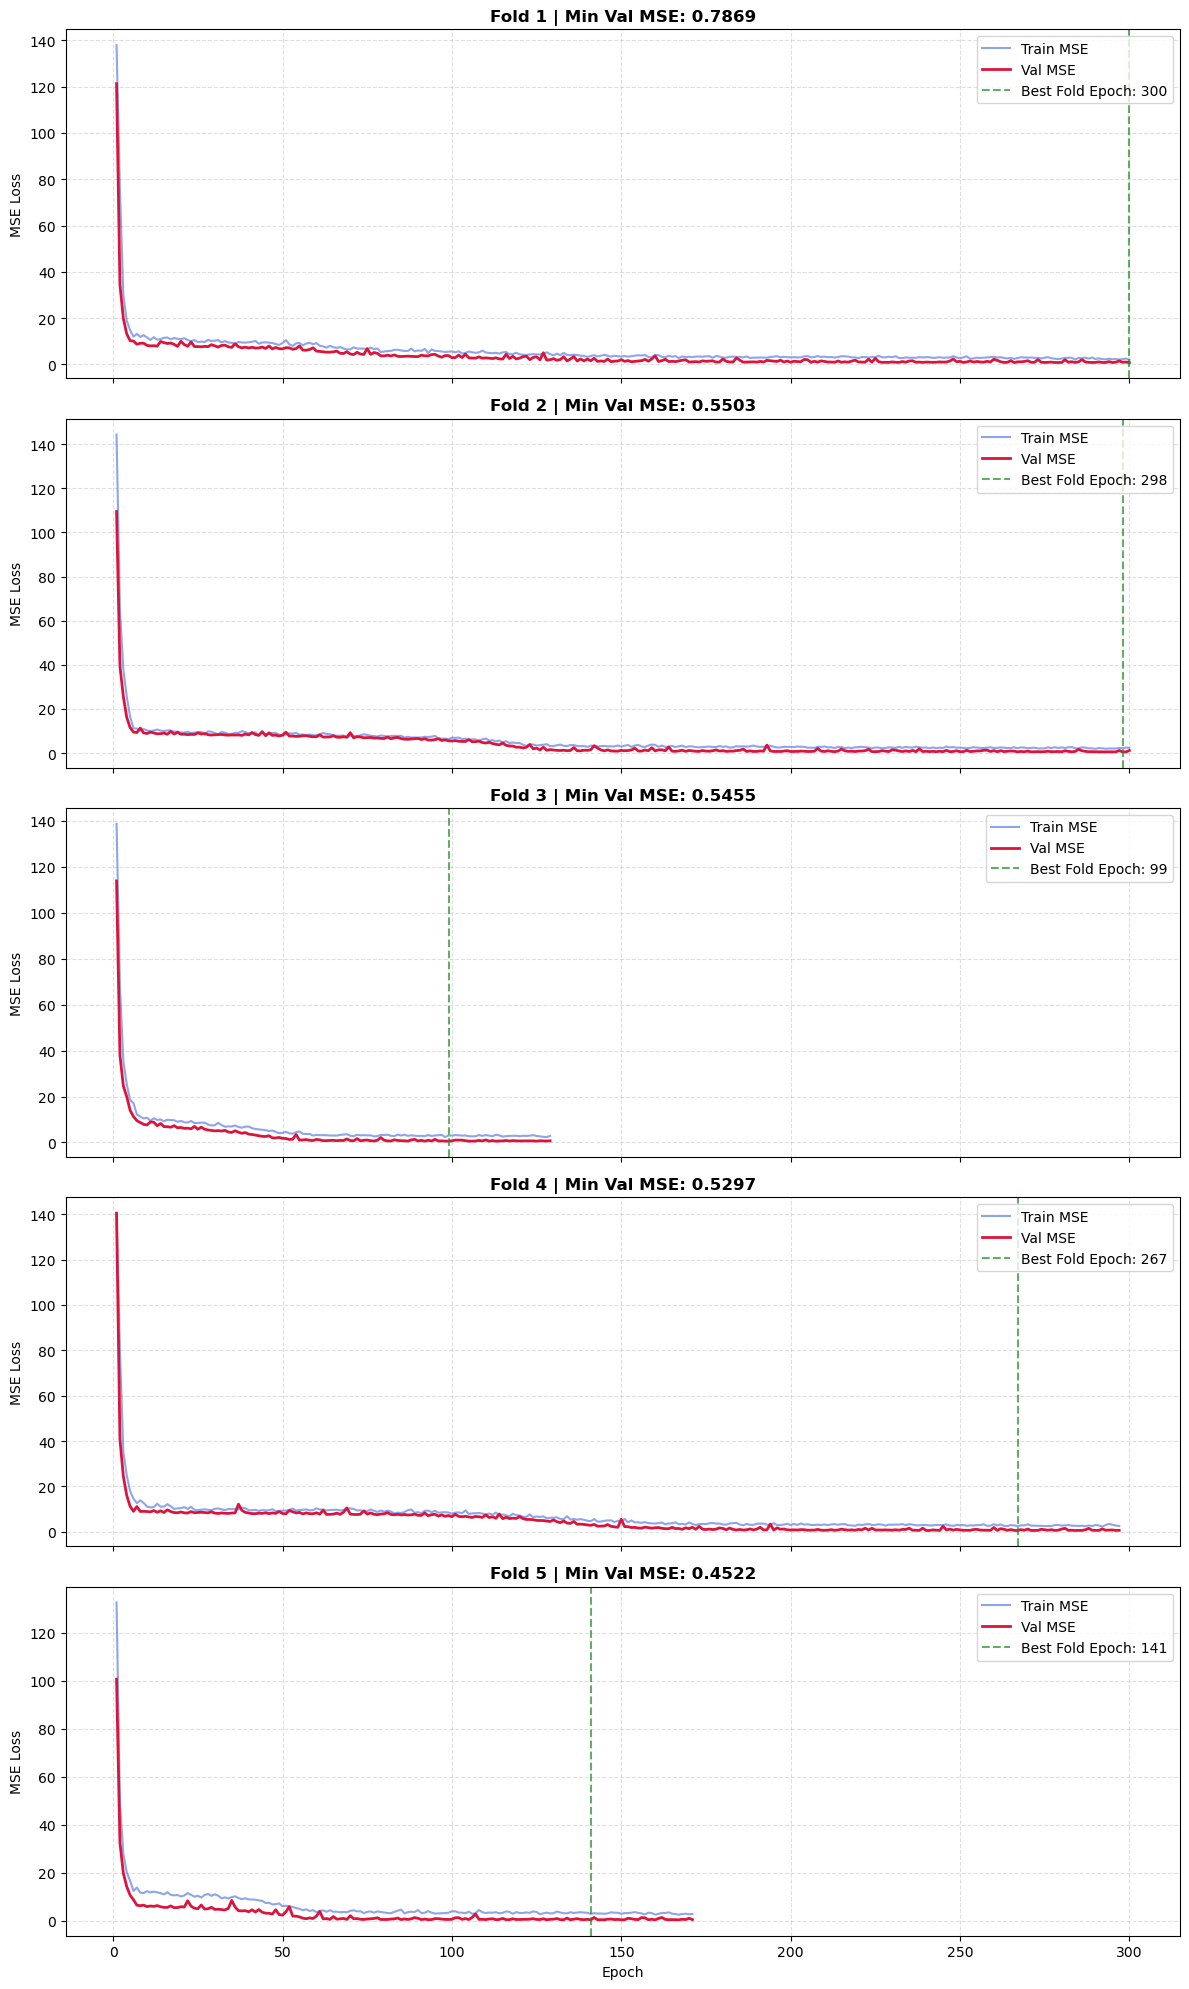

In [2]:
folds = sorted(df['Fold'].unique())
fig, axes = plt.subplots(len(folds), 1, figsize=(12, 4 * len(folds)), sharex=True)

# Ensure axes is iterable even if there is only 1 fold
if len(folds) == 1:
    axes = [axes]

for i, fold in enumerate(folds):
    fold_df = df[df['Fold'] == fold]
    ax = axes[i]
    
    ax.plot(fold_df['Epoch'], fold_df['Train_MSE'], label='Train MSE', color='royalblue', alpha=0.6)
    ax.plot(fold_df['Epoch'], fold_df['Val_MSE'], label='Val MSE', color='crimson', linewidth=2)
    
    # Identify the best epoch for this specific fold
    min_val_mse = fold_df['Val_MSE'].min()
    best_epoch_idx = fold_df['Val_MSE'].idxmin()
    min_epoch = fold_df.loc[best_epoch_idx, 'Epoch']
    
    ax.axvline(min_epoch, color='forestgreen', linestyle='--', alpha=0.7, 
               label=f'Best Fold Epoch: {min_epoch}')
    
    ax.set_title(f'Fold {fold} | Min Val MSE: {min_val_mse:.4f}', fontweight='bold')
    ax.set_ylabel('MSE Loss')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

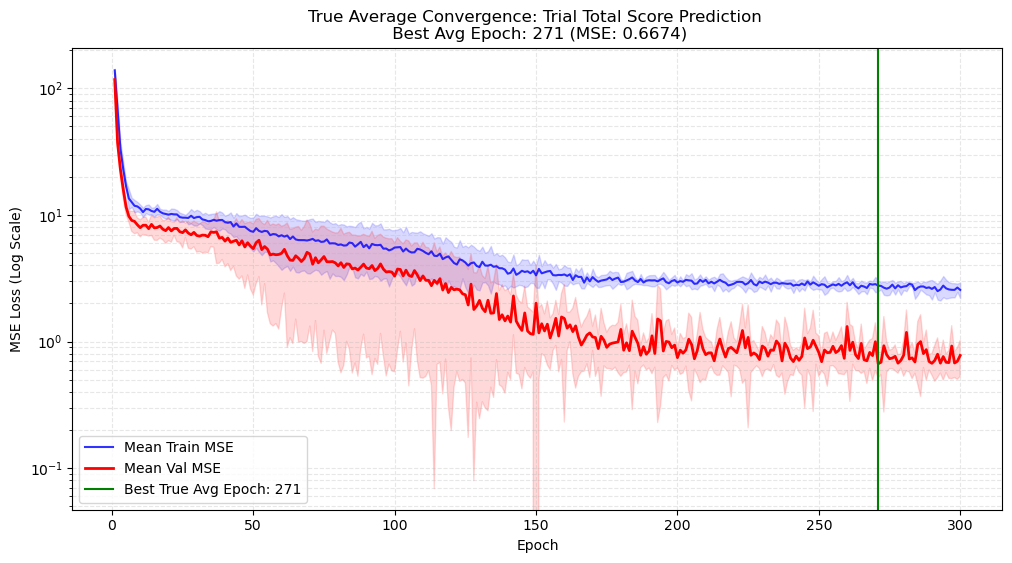

Convergence Note: The true 5-fold average stabilizes at epoch 271 with MSE 0.6674.


In [5]:
# 1. Pivot the data so Epochs are rows and Folds are columns
# 2. Forward-fill so early-stopped folds carry their final value forward
train_pivot = df.pivot(index='Epoch', columns='Fold', values='Train_MSE').ffill()
val_pivot = df.pivot(index='Epoch', columns='Fold', values='Val_MSE').ffill()

# 3. Calculate the true 5-fold mean and std for every epoch
mean_df = pd.DataFrame({
    'Train_MSE_mean': train_pivot.mean(axis=1),
    'Train_MSE_std': train_pivot.std(axis=1),
    'Val_MSE_mean': val_pivot.mean(axis=1),
    'Val_MSE_std': val_pivot.std(axis=1)
})

plt.figure(figsize=(12, 6))
epochs = mean_df.index
train_m, train_s = mean_df['Train_MSE_mean'], mean_df['Train_MSE_std']
val_m, val_s = mean_df['Val_MSE_mean'], mean_df['Val_MSE_std']

# Plotting Mean with Standard Deviation Shading
plt.plot(epochs, train_m, label='Mean Train MSE', color='blue', alpha=0.8)
plt.fill_between(epochs, train_m - train_s, train_m + train_s, alpha=0.15, color='blue')

plt.plot(epochs, val_m, label='Mean Val MSE', color='red', linewidth=2)
plt.fill_between(epochs, val_m - val_s, val_m + val_s, alpha=0.15, color='red')

# Find the point of best average convergence
min_avg_val_mse = val_m.min()
best_avg_epoch = val_m.idxmin()

plt.axvline(best_avg_epoch, color='green', linestyle='-', linewidth=1.5,
            label=f'Best True Avg Epoch: {best_avg_epoch}')

plt.yscale('log') # Log scale helps visualize convergence at low loss values
plt.title(f'True Average Convergence: Trial Total Score Prediction \n Best Avg Epoch: {best_avg_epoch} (MSE: {min_avg_val_mse:.4f})')
plt.ylabel('MSE Loss (Log Scale)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

print(f"Convergence Note: The true 5-fold average stabilizes at epoch {best_avg_epoch} with MSE {min_avg_val_mse:.4f}.")

In [6]:
# Extract metrics at the identified best average epoch
best_epoch_data = df[df['Epoch'] == best_avg_epoch]

summary_stats = best_epoch_data[METRIC_COLS].agg(['mean', 'std']).T
summary_stats.columns = ['Mean', 'Std Dev']

print(f"--- Final Metrics at Best Average Epoch ({best_avg_epoch}) ---")
# Using style.format for Jupyter or a standard print for scripts
try:
    from IPython.display import display
    display(summary_stats.style.format("{:.4f}").background_gradient(cmap='Greens', axis=0))
except ImportError:
    print(summary_stats.round(4))

# Final takeaway: R-Squared interpretation
avg_r2 = summary_stats.loc['Val_R2', 'Mean']
print(f"\nFinal Interpretation: Your model explains {avg_r2*100:.1f}% of the variance in total scores.")

--- Final Metrics at Best Average Epoch (271) ---


,Mean,Std Dev
Train_MSE,2.6782,0.3374
Val_MSE,0.6794,0.1971
Val_RMSE,0.8188,0.1158
Val_MAE,0.4969,0.0411
Val_R2,0.9856,0.0042



Final Interpretation: Your model explains 98.6% of the variance in total scores.
